In [189]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [191]:
data = pd.read_csv("D:/New folder/Feynn Labs Internship/mcdonalds.csv")
data

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender
0,No,Yes,No,Yes,No,Yes,Yes,No,Yes,No,No,-3,61,Every three months,Female
1,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,+2,51,Every three months,Female
2,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,+1,62,Every three months,Female
3,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,+4,69,Once a week,Female
4,No,Yes,No,Yes,Yes,Yes,Yes,No,No,Yes,No,+2,49,Once a month,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448,No,Yes,No,Yes,Yes,No,No,No,Yes,No,Yes,I hate it!-5,47,Once a year,Male
1449,Yes,Yes,No,Yes,No,No,Yes,Yes,No,Yes,No,+2,36,Once a week,Female
1450,Yes,Yes,No,Yes,No,Yes,No,Yes,Yes,No,No,+3,52,Once a month,Female
1451,Yes,Yes,No,No,No,Yes,Yes,Yes,No,Yes,No,+4,41,Every three months,Male


In [193]:
data.columns.tolist()

['yummy',
 'convenient',
 'spicy',
 'fattening',
 'greasy',
 'fast',
 'cheap',
 'tasty',
 'expensive',
 'healthy',
 'disgusting',
 'Like',
 'Age',
 'VisitFrequency',
 'Gender']

In [195]:
data.shape

(1453, 15)

In [197]:
data.head(3)

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender
0,No,Yes,No,Yes,No,Yes,Yes,No,Yes,No,No,-3,61,Every three months,Female
1,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,+2,51,Every three months,Female
2,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,+1,62,Every three months,Female


In [199]:

MD_x = data.iloc[:, 0:11]

In [201]:

MD_x = MD_x.applymap(lambda x: 1 if x == "Yes" else 0)
#MD_x=data.iloc[:,0:11].replace("Yes",1).replace("No",0)

In [203]:

MD_x

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting
0,0,1,0,1,0,1,1,0,1,0,0
1,1,1,0,1,1,1,1,1,1,0,0
2,0,1,1,1,1,1,0,1,1,1,0
3,1,1,0,1,1,1,1,1,0,0,1
4,0,1,0,1,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1448,0,1,0,1,1,0,0,0,1,0,1
1449,1,1,0,1,0,0,1,1,0,1,0
1450,1,1,0,1,0,1,0,1,1,0,0
1451,1,1,0,0,0,1,1,1,0,1,0


In [205]:
col_means = MD_x.mean().round(2)

In [207]:
col_means

yummy         0.55
convenient    0.91
spicy         0.09
fattening     0.87
greasy        0.53
fast          0.90
cheap         0.60
tasty         0.64
expensive     0.36
healthy       0.20
disgusting    0.24
dtype: float64

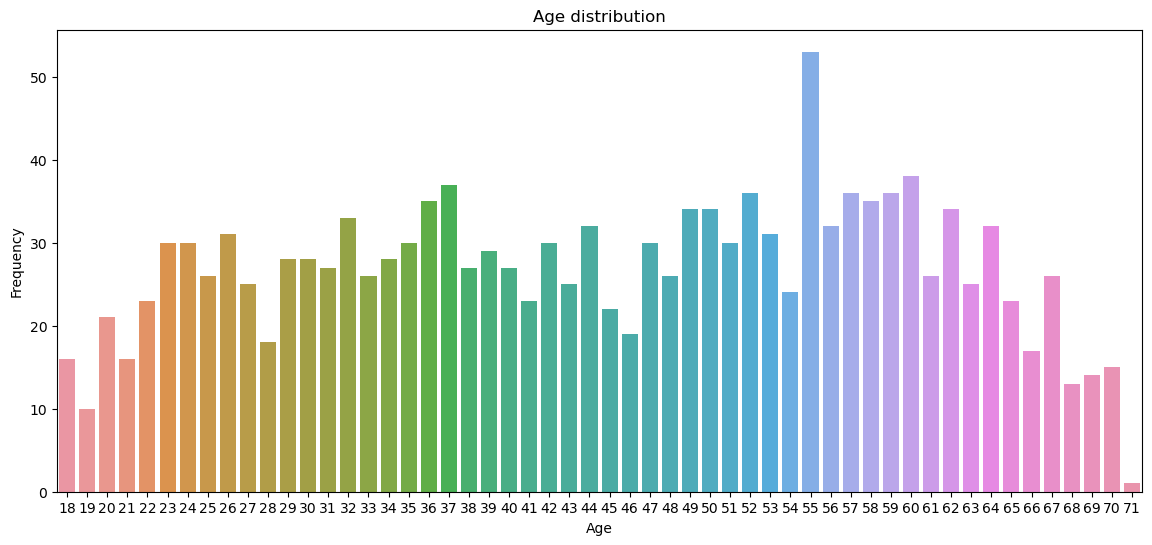

In [209]:

plt.figure(figsize = (14, 6))
sns.countplot(x = data['Age'])
plt.title('Age distribution')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

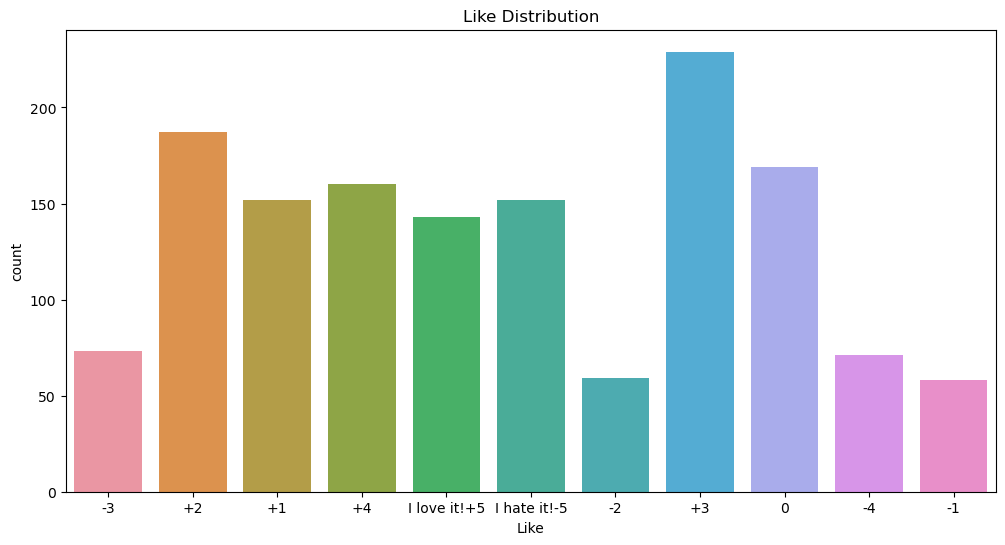

In [211]:
plt.figure(figsize = (12, 6))
sns.countplot(x = data['Like'])
plt.title('Like Distribution')
plt.show()

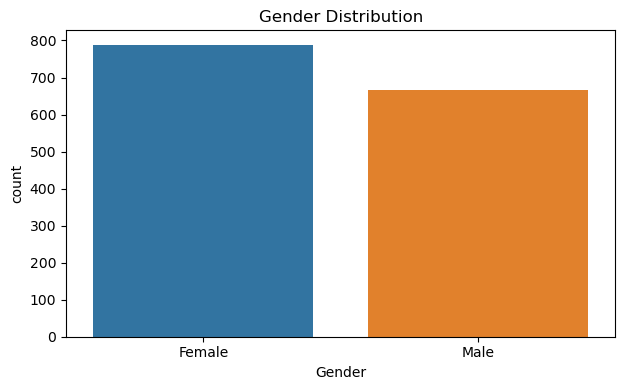

In [213]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
sns.countplot(x = data['Gender'])
plt.title('Gender Distribution')

plt.tight_layout()
plt.show()

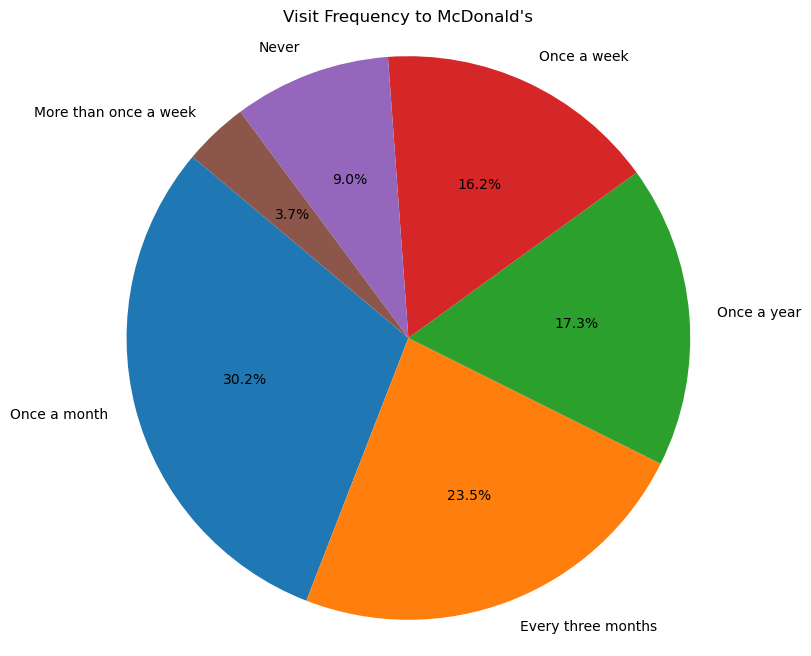

In [215]:
visit_frequency_counts = data['VisitFrequency'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(visit_frequency_counts, labels=visit_frequency_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Visit Frequency to McDonald\'s')
plt.axis('equal')  
plt.show()

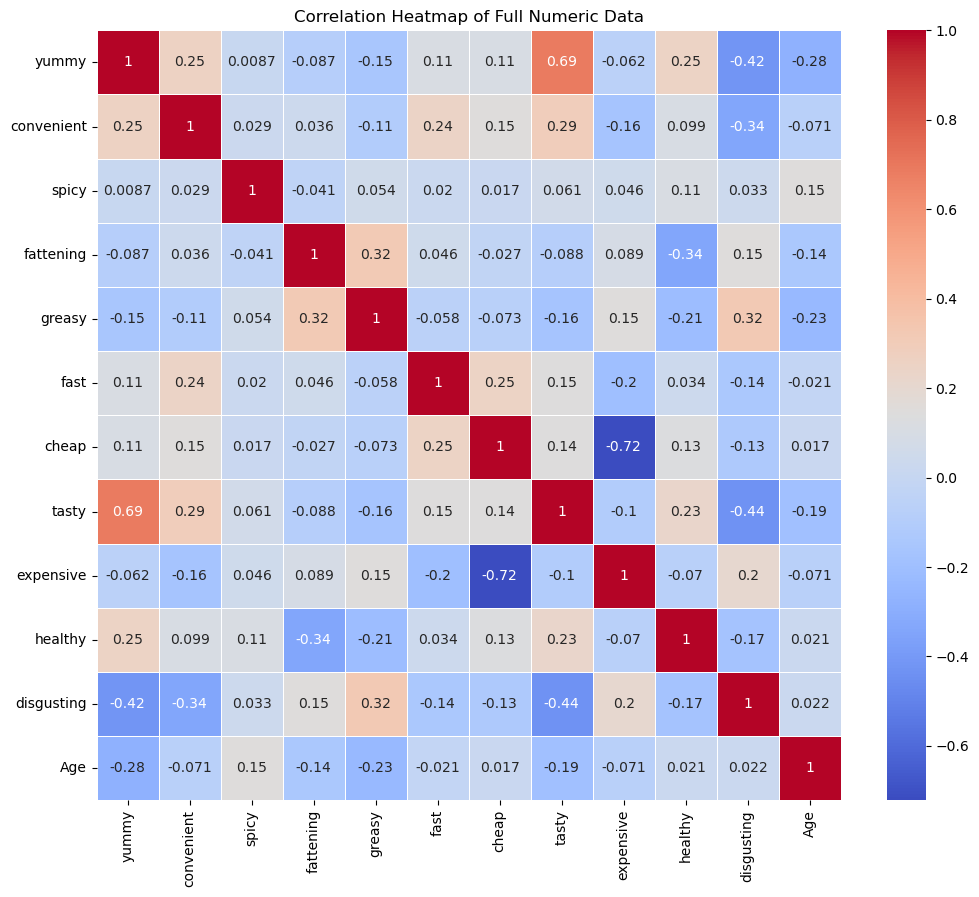

In [217]:
MD_x_full = data.columns[:11]
for col in MD_x_full:
    data[col] = data[col].map(lambda x: 1 if x == 'Yes' else 0)

numeric_data = data.select_dtypes(include=['number'])

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Full Numeric Data")
plt.show()


In [219]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from tabulate import tabulate

pca = PCA()
MD_pca = pca.fit_transform(MD_x)

summary_df = pd.DataFrame({
    "Principal Component": range(1, len(pca.explained_variance_) + 1),
    "Standard Deviation": np.sqrt(pca.explained_variance_),
    "Proportion of Variance": pca.explained_variance_ratio_,
})

In [221]:
summary_df

,Principal Component,Standard Deviation,Proportion of Variance
0,1,0.757050,0.299447
1,2,0.607456,0.192797
2,3,0.504619,0.133045
3,4,0.398799,0.083096
4,5,0.337405,0.059481
5,6,0.310275,0.050300
6,7,0.289697,0.043849
7,8,0.275122,0.039548
8,9,0.265251,0.036761
9,10,0.248842,0.032353


In [223]:
summary_df["Cumulative Proportion"] = summary_df["Proportion of Variance"].cumsum()

summary_df = summary_df.round(2)

summary_df = summary_df[['Principal Component', 'Standard Deviation', 'Proportion of Variance', 'Cumulative Proportion']]

print("PCA Summary:")
print(tabulate(summary_df, headers='keys', tablefmt='grid', showindex=False))


PCA Summary:
+-----------------------+----------------------+--------------------------+-------------------------+
|   Principal Component |   Standard Deviation |   Proportion of Variance |   Cumulative Proportion |
+=======================+======================+==========================+=========================+
|                     1 |                 0.76 |                     0.3  |                    0.3  |
+-----------------------+----------------------+--------------------------+-------------------------+
|                     2 |                 0.61 |                     0.19 |                    0.49 |
+-----------------------+----------------------+--------------------------+-------------------------+
|                     3 |                 0.5  |                     0.13 |                    0.63 |
+-----------------------+----------------------+--------------------------+-------------------------+
|                     4 |                 0.4  |                     

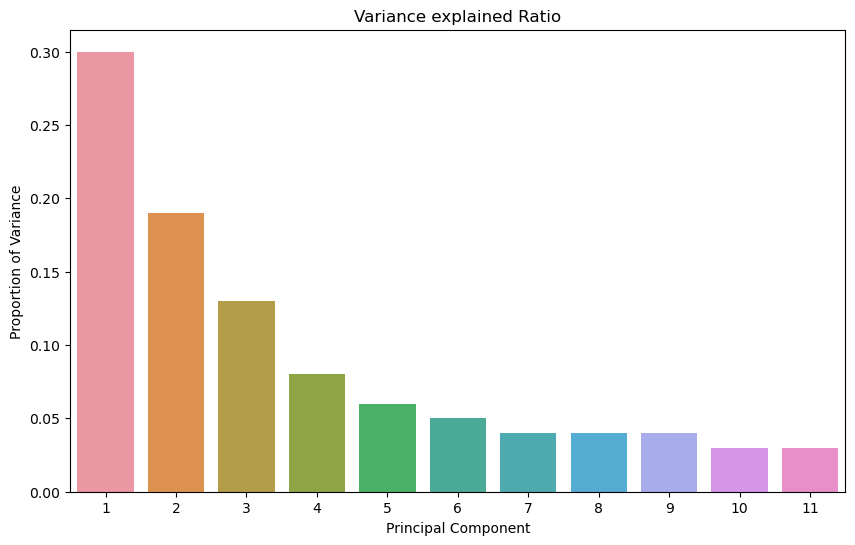

In [225]:
plt.figure(figsize=(10, 6))
sns.barplot(x=summary_df["Principal Component"], y=summary_df["Proportion of Variance"])
plt.title('Variance explained Ratio')
plt.show()

As we can see about 50% of the variance is explained just by first two components and about 63% of the variance is explained just by first three component.

In [229]:

loadings = pd.DataFrame(
    pca.components_.T,  
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=MD_x.columns  
)

loadings = loadings.round(2)

print("\nPCA Loadings:")
print(tabulate(loadings, headers='keys', tablefmt='grid'))


PCA Loadings:
+------------+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+--------+
|            |   PC1 |   PC2 |   PC3 |   PC4 |   PC5 |   PC6 |   PC7 |   PC8 |   PC9 |   PC10 |   PC11 |
+============+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+========+
| yummy      | -0.48 |  0.36 | -0.3  |  0.06 | -0.31 |  0.17 | -0.28 |  0.01 |  0.57 |  -0.11 |   0.05 |
+------------+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+--------+
| convenient | -0.16 |  0.02 | -0.06 | -0.14 |  0.28 | -0.35 | -0.06 | -0.11 | -0.02 |  -0.67 |  -0.54 |
+------------+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+--------+
| spicy      | -0.01 |  0.02 | -0.04 |  0.2  |  0.07 | -0.36 |  0.71 |  0.38 |  0.4  |  -0.08 |   0.14 |
+------------+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+--------+
| fattening  |  0.12 | -0.03 | -0.32 | -

##### PCA loading is the correlation or weight between an original variable and a principal component or in other wrds, loading is the coefficient of an original variable in the linear combination that defines a principal component.

##### A high positive loading means that variable strongly contributes in a positive direction to that PC.
##### A high negative loading means it contributes negatively.
##### Loadings close to 0 mean the variable doesn’t influence that component much.

Text(0.5, 1.0, 'PCA Projection with Loadings')

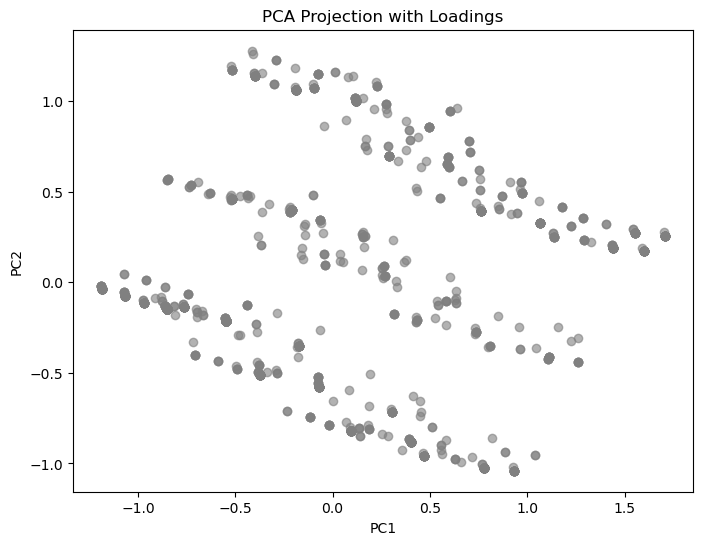

In [233]:
plt.figure(figsize=(8, 6))
plt.scatter(MD_pca[:, 0], MD_pca[:, 1], color='grey', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection with Loadings')

In [82]:
loadings.shape

(11, 11)

### Extracting Segments

#### K-Means Cluster

First Approach - scree plot

Text(0, 0.5, 'Within-cluster Sum of Squares')

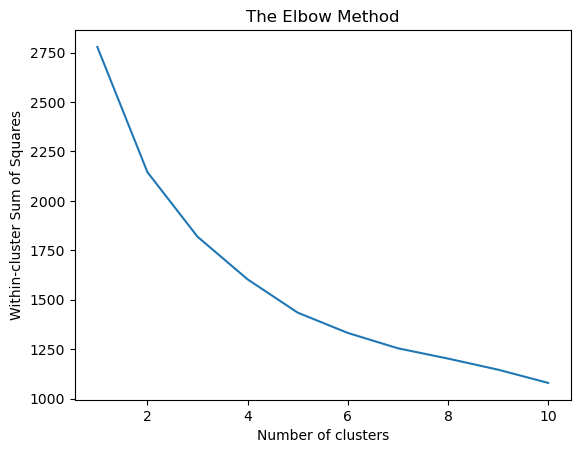

In [235]:
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(MD_x)
    wcss.append(kmeans.inertia_)

number_clusters = range(1,11)
plt.plot(number_clusters, wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Within-cluster Sum of Squares')

Text(0.5, 1.0, 'Kmeans')

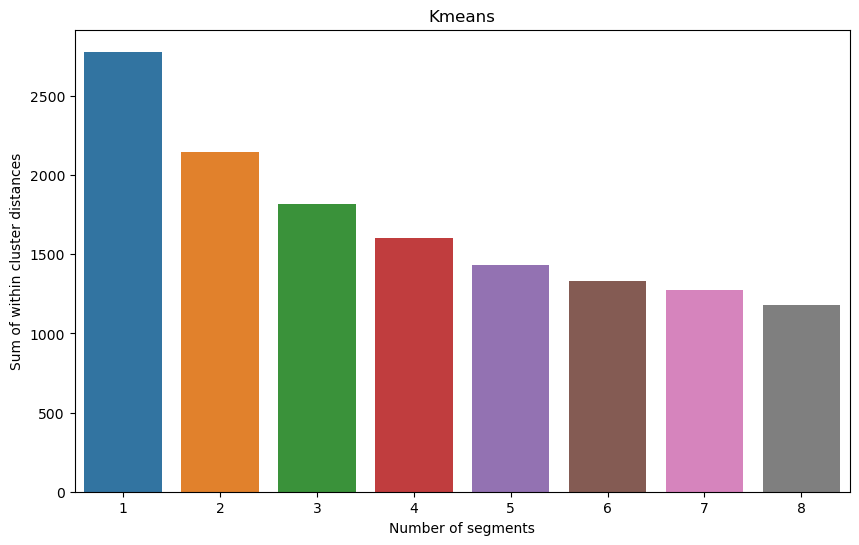

In [237]:

cluster_interia = []
n_clusters = []

for k in range(1, 9):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(MD_x)
    cluster_interia.append(kmeans.inertia_)
    n_clusters.append(k)

plt.figure(figsize = (10, 6))
sns.barplot(x = n_clusters, y = cluster_interia)
plt.xlabel('Number of segments')
plt.ylabel('Sum of within cluster distances')
plt.title('Kmeans')

The scree plot has no distinct elbow: the sum of distances within
market segments drops slowly as the number of market segments increases. So this plot does not provide useful guidance
on the number of market segments to extract.

Second Approach - stability-based data structure analysis

In [156]:
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample

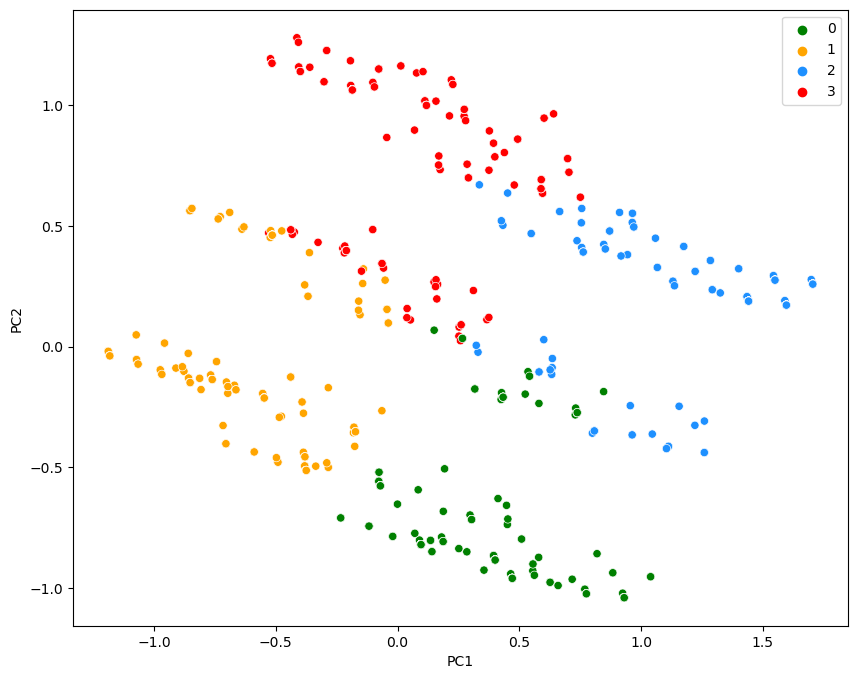

In [253]:
kmeans=KMeans(4)
kmeans.fit(MD_x)

pred = kmeans.predict(MD_x)

plt.figure(figsize = (10, 8))

sns.scatterplot(x = MD_pca[:, 0], y = MD_pca[:, 1], hue = pred,
                palette=['green','orange','dodgerblue','red'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


In [247]:
MD_pca

array([[ 0.42536706, -0.21907878,  0.6632553 , ...,  0.18100693,
         0.51570617, -0.56707389],
       [-0.21863768,  0.38818996, -0.73082668, ...,  0.11147641,
         0.49331285, -0.50044033],
       [ 0.37541475,  0.73043507, -0.12203978, ..., -0.32228786,
         0.06175857,  0.24274108],
       ...,
       [-0.18589445,  1.06266156,  0.22085675, ...,  0.03825472,
         0.05651822, -0.01279977],
       [-1.18206441, -0.03856977,  0.56156066, ...,  0.02226748,
        -0.00257265, -0.10531631],
       [ 1.55024186,  0.27503101, -0.01373727, ..., -0.13658866,
        -0.43279782, -0.45607556]])

#### Using Mixture of Distributions

In [255]:
import numpy as np
import pandas as pd
from scipy.stats import entropy
from sklearn.cluster import KMeans

np.random.seed(1234)
k_values = range(2, 9)
MD_m28 = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=1234)
    model.fit(MD_x)  
    iter_val = model.n_iter_
    converged = model.n_init == 1 or model.inertia_ < 1e-10
    k_val = k
    k0_val = k
    log_likelihood = -model.inertia_
    n_samples, _ = MD_x.shape
    aic = -2 * log_likelihood + 2 * k
    bic = -2 * log_likelihood + np.log(n_samples) * k
    labels = model.labels_
    counts = np.bincount(labels)
    probs = counts / float(counts.sum())
    class_entropy = entropy(probs)
    icl = bic - class_entropy
    
    MD_m28.append((iter_val, converged, k_val, k0_val, log_likelihood, aic, bic, icl))

MD_m28 = pd.DataFrame(MD_m28, columns=['iter', 'converged', 'k', 'k0', 'logLik', 'AIC', 'BIC', 'ICL'])
from tabulate import tabulate


print(tabulate(MD_m28, headers='keys', tablefmt='grid', showindex=False))


+--------+-------------+-----+------+----------+---------+---------+---------+
|   iter | converged   |   k |   k0 |   logLik |     AIC |     BIC |     ICL |
+========+=============+=====+======+==========+=========+=========+=========+
|      6 | False       |   2 |    2 | -2145.5  | 4295.01 | 4305.57 | 4304.9  |
+--------+-------------+-----+------+----------+---------+---------+---------+
|      5 | False       |   3 |    3 | -1818.71 | 3643.42 | 3659.26 | 3658.19 |
+--------+-------------+-----+------+----------+---------+---------+---------+
|      9 | False       |   4 |    4 | -1604.11 | 3216.21 | 3237.34 | 3235.99 |
+--------+-------------+-----+------+----------+---------+---------+---------+
|     11 | False       |   5 |    5 | -1434.61 | 2879.22 | 2905.63 | 2904.04 |
+--------+-------------+-----+------+----------+---------+---------+---------+
|      7 | False       |   6 |    6 | -1331.65 | 2675.3  | 2706.99 | 2705.23 |
+--------+-------------+-----+------+----------+----

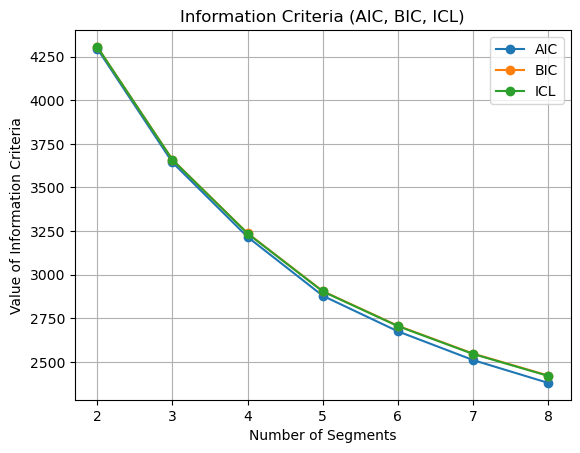

In [257]:
import matplotlib.pyplot as plt

num_segments = MD_m28["k"]
AIC_values = MD_m28["AIC"]
BIC_values = MD_m28["BIC"]
ICL_values = MD_m28["ICL"]

plt.plot(num_segments, AIC_values, marker='o', label='AIC')
plt.plot(num_segments, BIC_values, marker='o', label='BIC')
plt.plot(num_segments, ICL_values, marker='o', label='ICL')

plt.xlabel('Number of Segments')
plt.ylabel('Value of Information Criteria')
plt.title('Information Criteria (AIC, BIC, ICL)')
plt.legend()
plt.grid(True)

plt.show()

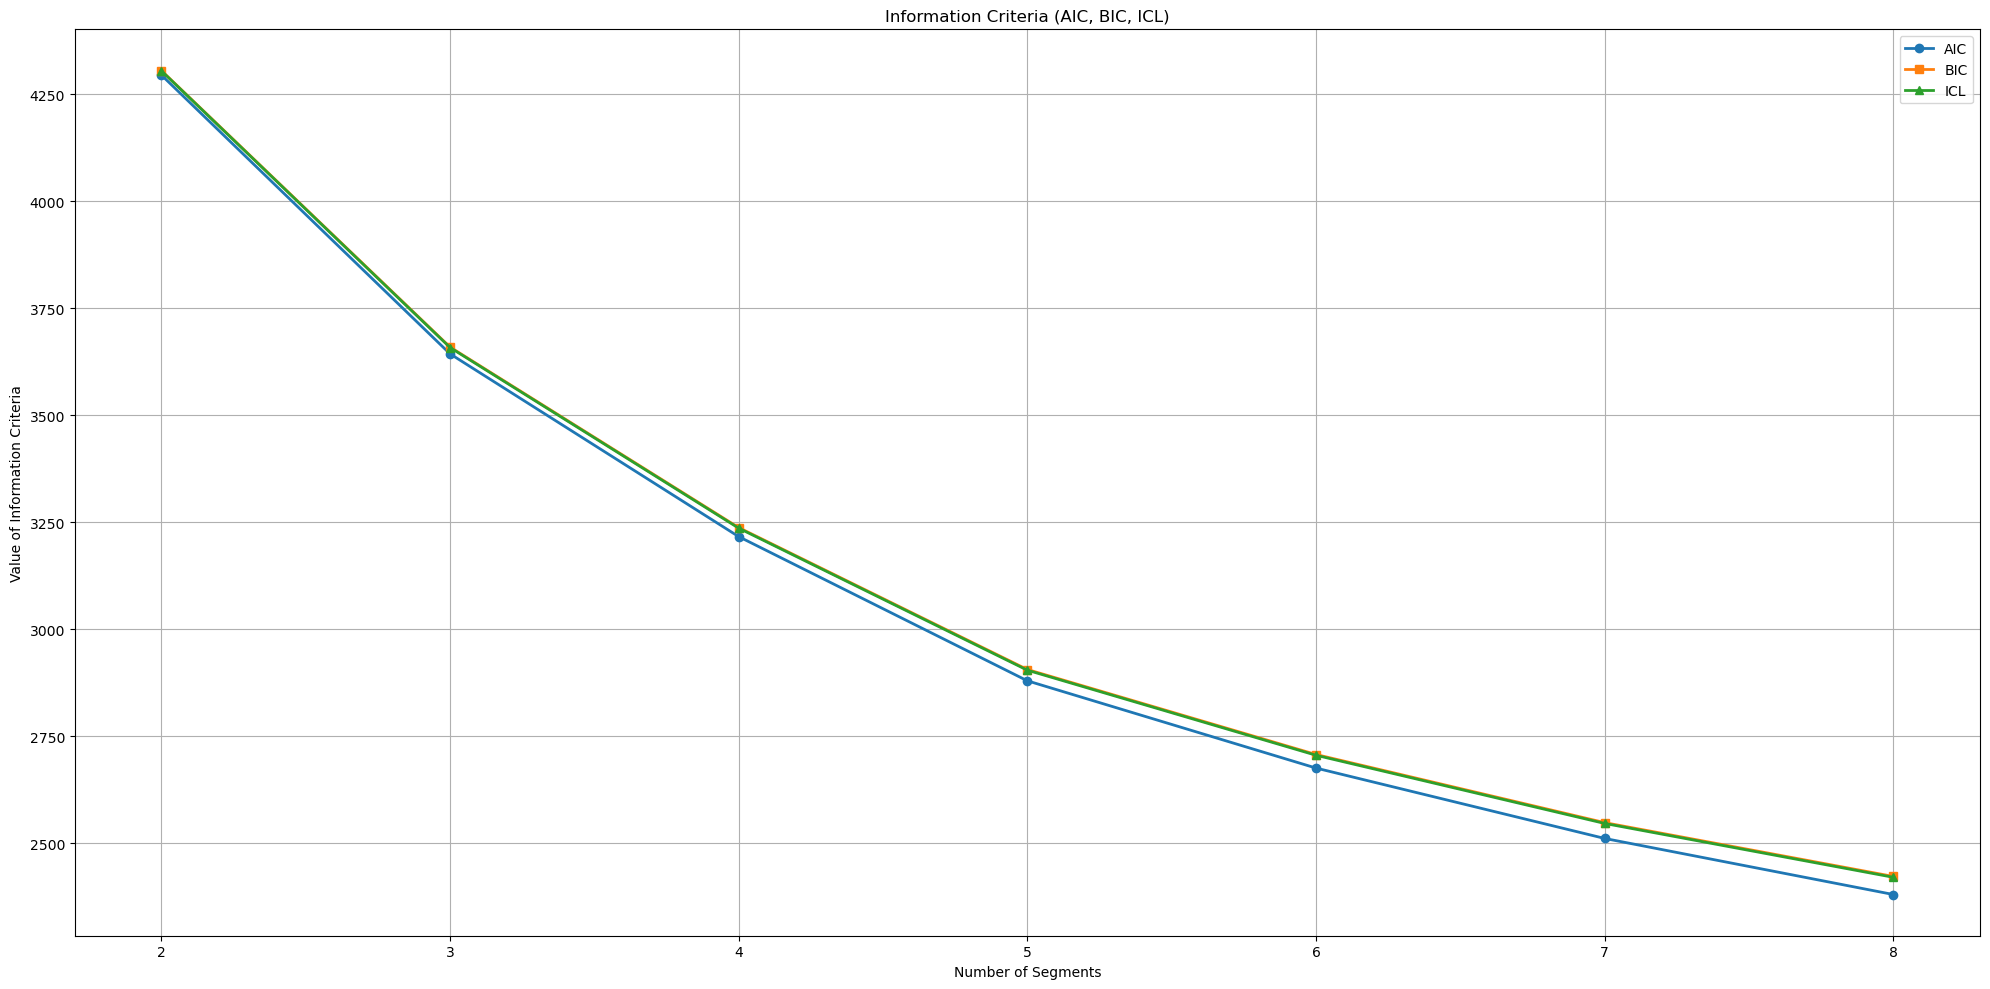

In [263]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))  # wider and taller plot

plt.plot(num_segments, AIC_values, marker='o', label='AIC', linewidth=2)
plt.plot(num_segments, BIC_values, marker='s', label='BIC', linewidth=2)
plt.plot(num_segments, ICL_values, marker='^', label='ICL', linewidth=2)

plt.xlabel('Number of Segments')
plt.ylabel('Value of Information Criteria')
plt.title('Information Criteria (AIC, BIC, ICL)')
plt.legend()
plt.grid(True)
plt.tight_layout()  # adjusts spacing to prevent clipping

plt.show()


In [265]:
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from tabulate import tabulate

k = 4
kmeans = KMeans(n_clusters=k, random_state=1234)
kmeans.fit(MD_x)
kmeans_clusters = kmeans.predict(MD_x)

gmm = GaussianMixture(n_components=k, random_state=1234)
gmm.fit(MD_x)
gmm_clusters = gmm.predict(MD_x)

results = pd.DataFrame({'kmeans': kmeans_clusters, 'mixture': gmm_clusters})

MD_m4 = MD_x[results['mixture'] == 3] 

k4_m4 = KMeans(n_clusters=k, random_state=1234)
k4_m4.fit(MD_m4)
k4_m4_clusters = k4_m4.predict(MD_m4)

results_m4 = pd.DataFrame({'kmeans': k4_m4_clusters, 'mixture': 3})

cross_tab1 = pd.crosstab(results['kmeans'], results['mixture'])
cross_tab2 = pd.crosstab(results['kmeans'], results_m4['kmeans'])

print("Cross-tabulation Results (kmeans vs. mixture):")
print(tabulate(cross_tab1, headers='keys', tablefmt='grid'))

print("\nCross-tabulation Results (kmeans vs. kmeans for MD_m4):")
print(tabulate(cross_tab2, headers='keys', tablefmt='grid'))


Cross-tabulation Results (kmeans vs. mixture):
+----------+-----+-----+-----+-----+
|   kmeans |   0 |   1 |   2 |   3 |
+==========+=====+=====+=====+=====+
|        0 |   3 | 123 |   7 | 380 |
+----------+-----+-----+-----+-----+
|        1 |   6 |   6 | 261 |  93 |
+----------+-----+-----+-----+-----+
|        2 | 202 |   0 |  24 |  16 |
+----------+-----+-----+-----+-----+
|        3 |  18 |  74 |   6 | 234 |
+----------+-----+-----+-----+-----+

Cross-tabulation Results (kmeans vs. kmeans for MD_m4):
+----------+-----+-----+-----+-----+
|   kmeans |   0 |   1 |   2 |   3 |
+==========+=====+=====+=====+=====+
|        0 |  44 |  68 |  74 |  78 |
+----------+-----+-----+-----+-----+
|        1 |  23 |  50 |  42 |  55 |
+----------+-----+-----+-----+-----+
|        2 |  21 |  35 |  32 |  25 |
+----------+-----+-----+-----+-----+
|        3 |  23 |  41 |  48 |  64 |
+----------+-----+-----+-----+-----+


In [267]:
from sklearn.mixture import GaussianMixture
import numpy as np

gmm_m4a = GaussianMixture(n_components=4)
gmm_m4a.fit(MD_x)

log_likelihood_m4a = gmm_m4a.score(MD_x)

gmm_m4 = GaussianMixture(n_components=4)
gmm_m4.fit(MD_x)

log_likelihood_m4 = gmm_m4.score(MD_x)

print("Log-likelihood for MD_x.m4a:", log_likelihood_m4a)
print("Log-likelihood for MD_x.m4:", log_likelihood_m4)


Log-likelihood for MD_x.m4a: 11.883738586718454
Log-likelihood for MD_x.m4: 9.411739276020775


#### Using Mixture of Regression Models

In [271]:
import numpy as np
import pandas as pd
from tabulate import tabulate

like_mapping = {
    'I HATE IT!-5': -5,
    '-4': -4,
    '-3': -3,
    '-2': -2,
    '-1': -1,
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    'I LOVE IT!+5': 5
}

data['Like.n'] = data['Like'].map(like_mapping)

like_n_counts = data['Like.n'].value_counts().reset_index()
like_n_counts.columns = ['Numeric Value', 'Count']

# Print in a neat tabular format
print(tabulate(like_n_counts, headers='keys', tablefmt='pretty'))


+---+---------------+-------+
|   | Numeric Value | Count |
+---+---------------+-------+
| 0 |      0.0      | 169.0 |
| 1 |     -3.0      | 73.0  |
| 2 |     -4.0      | 71.0  |
| 3 |     -2.0      | 59.0  |
| 4 |     -1.0      | 58.0  |
+---+---------------+-------+


In [273]:
from patsy import dmatrices

independent_vars = data.columns[0:11] 

formula_str = ' + '.join(independent_vars)

formula_str = 'Like ~ ' + formula_str


f = dmatrices(formula_str, data=data)[1]

print(f)


[[1. 0. 1. ... 1. 0. 0.]
 [1. 1. 1. ... 1. 0. 0.]
 [1. 0. 1. ... 1. 1. 0.]
 ...
 [1. 1. 1. ... 1. 0. 0.]
 [1. 1. 1. ... 0. 1. 0.]
 [1. 0. 1. ... 1. 0. 1.]]


In [275]:
from sklearn.mixture import GaussianMixture
from patsy import dmatrix
np.random.seed(1234)

X = dmatrix(f.design_info, data=data)
y = dmatrix('Like', data=data)

n_components = 2
n_init = 10
verbose = False
n_rep=10

model = GaussianMixture(n_components=n_components, n_init=n_init, verbose=verbose)
MD_reg2 = model.fit(X, y)

print(MD_reg2)
cluster_sizes = np.bincount(model.predict(X))

print("Cluster sizes:")
for i, size in enumerate(cluster_sizes):
    print(f"{i+1}: {size}")


GaussianMixture(n_components=2, n_init=10, verbose=False)
Cluster sizes:
1: 468
2: 985


### Profiling Segments

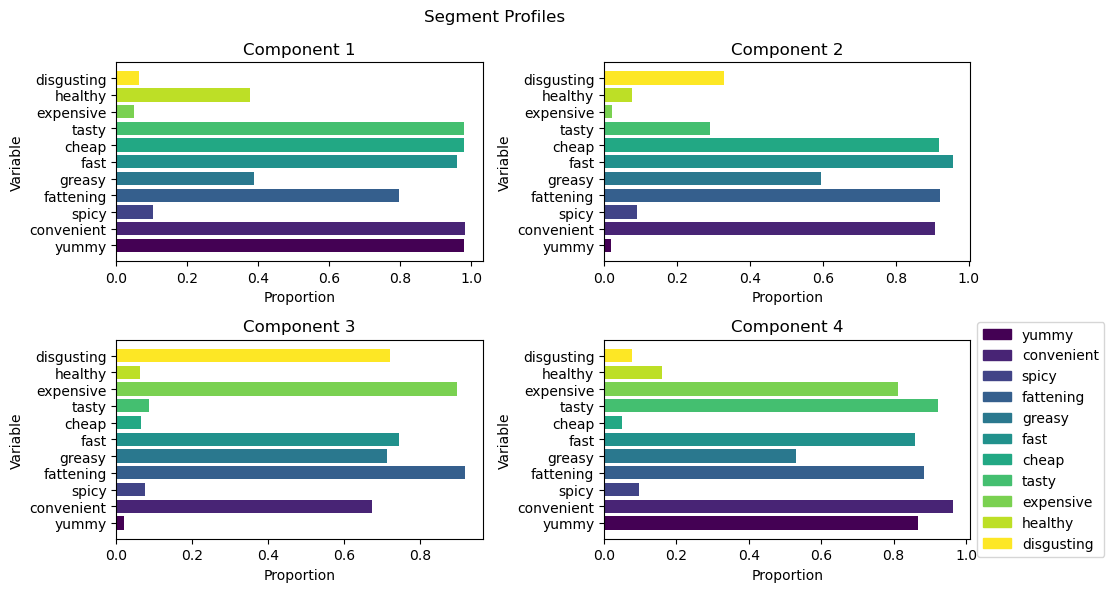

In [278]:
kmeans = MD_km28['4']

labels = kmeans.labels_

MD_mean = MD_x.groupby(labels).mean()

fig, axs = plt.subplots(2, 2, figsize=(10, 6))

color_map = plt.cm.get_cmap('viridis', len(MD_x.columns))

for i in range(4):
    num_variables = MD_mean.shape[1]
    num_segments = MD_mean.shape[0]
    bars = []

    for j in range(num_variables):
        color = color_map(j / num_variables)  
        bar = axs[i // 2, i % 2].barh(j, MD_mean.iloc[i, j], color=color)
        bars.append(bar)

    axs[i // 2, i % 2].set_title(f'Component {i + 1}')
    axs[i // 2, i % 2].set(ylabel='Variable', xlabel='Proportion')
    axs[i // 2, i % 2].set_yticks(range(num_variables))
    axs[i // 2, i % 2].set_yticklabels(MD_x.columns)

fig.suptitle('Segment Profiles')

fig.tight_layout()

# Create a legend with variable names and corresponding colors
handles = [plt.Rectangle((0, 0), 1, 1, color=color_map(i / num_variables)) for i in range(num_variables)]
plt.legend(handles, MD_x.columns, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

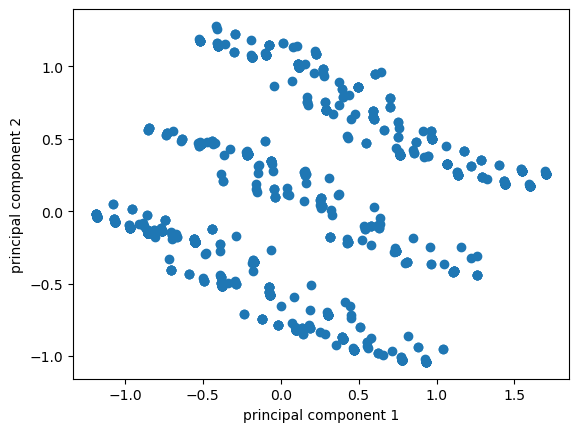

In [280]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=4)
kmeans.fit(MD_x)

pca = PCA(n_components=2)
MD_pca = pca.fit_transform(MD_x)

fig, ax = plt.subplots()

ax.scatter(MD_pca[:, 0], MD_pca[:, 1])
ax.set_xlabel('principal component 1')
ax.set_ylabel('principal component 2')
plt.show()




### Describing Segments

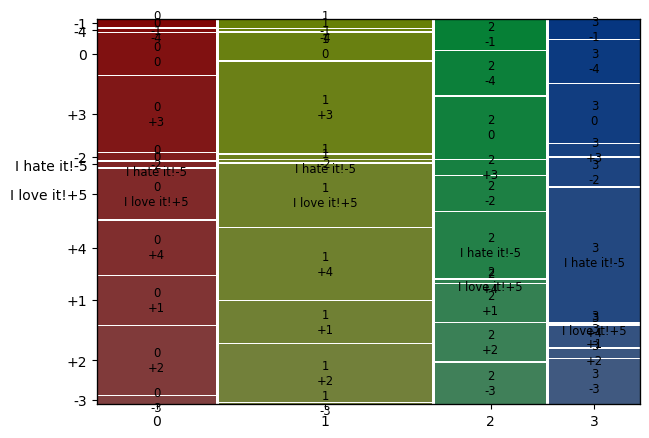

In [285]:
from statsmodels.graphics.mosaicplot import mosaic
from sklearn.preprocessing import LabelEncoder

def labelling(x):
    data[x] = LabelEncoder().fit_transform(data[x])
    return data

cat = ['yummy', 'convenient', 'spicy', 'fattening', 'greasy', 'fast', 'cheap',
       'tasty', 'expensive', 'healthy', 'disgusting']

for i in cat:
    labelling(i)

df_eleven = data.loc[:, cat]

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=0).fit(df_eleven)
data['cluster_num'] = kmeans.labels_ 


unique_like_values = data['Like'].unique()


crosstab = pd.crosstab(data['cluster_num'], data['Like'])


crosstab = crosstab[unique_like_values]

plt.rcParams['figure.figsize'] = (7, 5)
mosaic(crosstab.stack())
plt.show()


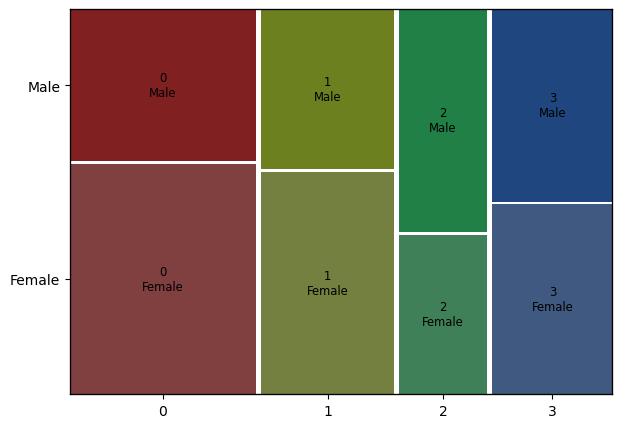

In [287]:
from statsmodels.graphics.mosaicplot import mosaic

MD_k4=MD_km28['4']
k4 = MD_k4.labels_

ct = pd.crosstab(k4, data['Gender'])
ct
mosaic(ct.stack(),gap=0.01)

plt.show()

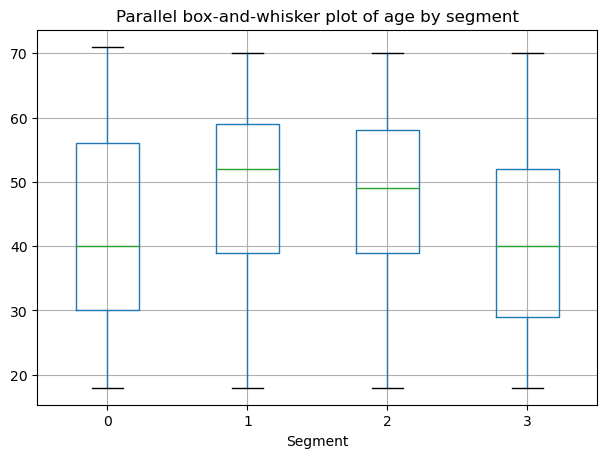

In [289]:
df = pd.DataFrame({'Segment': k4, 'Age': data['Age']})

df.boxplot(by='Segment', column='Age')
plt.title('Parallel box-and-whisker plot of age by segment')
plt.suptitle('')
plt.show()

### Selecting the Target Segments

In [307]:
data['Like'] = LabelEncoder().fit_transform(data['Like'])
Like = data.groupby('cluster_num')['Like'].mean()
Like = Like.to_frame().reset_index()
Like

,cluster_num,Like
0,0,3.798762
1,1,3.794828
2,2,5.430921
3,3,6.739837


In [303]:

data['Gender'] = LabelEncoder().fit_transform(data['Gender'])
Gender = data.groupby('cluster_num')['Gender'].mean()
Gender = Gender.to_frame().reset_index()
Gender

,cluster_num,Gender
0,0,0.523220
1,1,0.398276
2,2,0.411184
3,3,0.569106


In [311]:
data['VisitFrequency'] = LabelEncoder().fit_transform(data['VisitFrequency'])
visit = data.groupby('cluster_num')['VisitFrequency'].mean()
visit = visit.to_frame().reset_index()
visit

,cluster_num,VisitFrequency
0,0,2.547988
1,1,2.584483
2,2,2.822368
3,3,2.654472


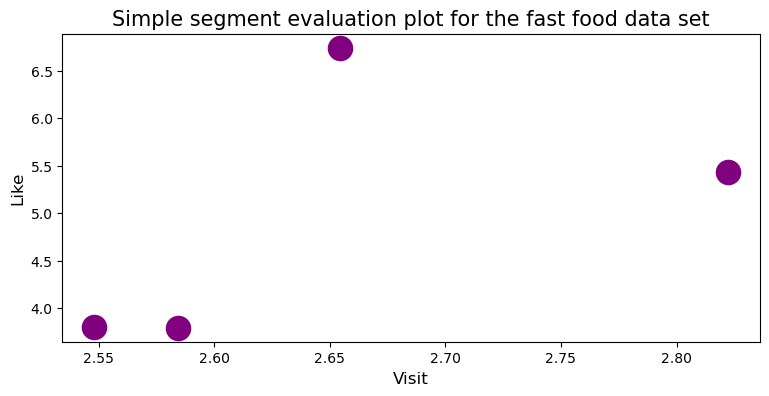

In [313]:
import seaborn as sns
segment = Gender.merge(Like, on='cluster_num', how='left').merge(visit, on='cluster_num', how='left')
segment
plt.figure(figsize = (9,4))
sns.scatterplot(x = "VisitFrequency", y = "Like",data=segment,s=400, color="purple")
plt.title("Simple segment evaluation plot for the fast food data set",fontsize = 15) 
plt.xlabel("Visit", fontsize = 12) 
plt.ylabel("Like", fontsize = 12) 
plt.show()